In [1]:
%load_ext autoreload
%autoreload 2
from hypnose_behavior.utils.helpers import print_cache_keys
from hypnose_behavior.visualization.accuracy import (
    plot_decision_accuracy,
    plot_decision_accuracy_by_odor,
    plot_decision_accuracy_rolling_average,
)
from hypnose_behavior.visualization.choice import plot_choice_history
from hypnose_behavior.visualization.false_alarm import (
    plot_abortion_and_fa_rates,
    plot_fa_ratio_a_over_sessions,
    plot_fa_ratio_by_abort_odor,
    plot_false_alarm_rate_by_position,
)
from hypnose_behavior.visualization.hidden_rule import (
    hidden_rule_and_false_alarm,
    plot_fa_ratio_by_hr_position,
    plot_hidden_rule_abort_poke_gap,
    plot_hr_reward_fraction_over_trials,
)
from hypnose_behavior.visualization.overview import plot_behavior_metrics
from hypnose_behavior.visualization.sampling import (
    plot_poke_duration_by_odor,
    plot_poke_duration_by_position,
    plot_sampling_times_analysis,
)
from hypnose_behavior.visualization.sequence import plot_position_completion_rate
from hypnose_behavior.visualization.timing import (
    plot_iti_over_time,
    plot_latency_over_time,
    plot_response_times_completed_vs_fa,
)
from hypnose_behavior.io.save import use_style
%matplotlib widget

use_style("presentation")

# 1. Metrics Visualization

In [6]:
quintuples = {
    60: (20260819, 20260902),
    61: (20260819, 20260902),
    62: (20260819, 20260902),
    63: (20260903, 20260908),
    65: (20260915, 20260921),
    66: (20260819, 20260902),
}

hidden_rule = {
    60: (20260903, 20261001),
    61: (20260903, 20261001),
    62: (20260903, 20261001),
    63: (20260909, 20260929),
    65: (20260925, 20261001),
    66: (20260903, 20260928),
}

quintuples_old = {
    40: (20251118, 20251120),
    45: (20260126, 20260129),
    48: (20260127, 20260129),
    50: (20260202, 20260204),
}

probes = {
    40: (20251121, 20251124),
    45: (20260130, 20260212),
    48: (20260130, 20260204),
    50: (20260205, 20260216),
}

hidden_rule_old = {
    40: (20251125, 20251231),
    45: (20260213, 20260306),
    48: (20260205, 20260306),
    50: (20260225, 20260313),
}

hidden_rule_21_sessions = {
    40: (20251125, 20251223),
    45: (20260213, 20260306),
    48: (20260205, 20260306),
    50: (20260225, 20260313),
}

all = {
    40: (20251118, 20251231),
    45: (20260126, 20260306),
    48: (20260127, 20260306),
    50: (20260202, 20260313)}

quintuples_and_probes = {
    40: (20251118, 20251124),
    45: (20260126, 20260212),
    48: (20260127, 20260204),
    50: (20260202, 20260216)}

In [ ]:
# Plots response times for completes trials vs early choice trials as boxplots
fig, ax = plot_response_times_completed_vs_fa(subjid=all, dates=dates, y_limit=5000, save=True)

In [ ]:
# Per odor plots bias if FA are for port A or B
figs = plot_fa_ratio_a_over_sessions(subjid, dates=dates)

In [ ]:
# Plots Early Choice and Abortion rates as boxplots across sessions for each position and odor. Can set what FA types to include and whether to include non-initiated trials in FA. 
fig, axes = plot_abortion_and_fa_rates(subjid, dates=dates, include_noninitiated_in_fa_odor=False, fa_types='FA_time_in', save=True) #can use one or more FA Type filter, or 'All'. E.g., use 'FA_time_in,FA_time_out'

In [ ]:
# Plots if FAs are more often to reward port A or B for each odor, if FA is at that odor, one position after, or anywhere after. 
# Can filter by FA types: 'FA_time_in', 'FA_time_out', 'FA_late', or combinations like 'FA_time_in,FA_time_out'
# Can also exclude FAs at a specific position with exclude_last_pos=True (by default set to pos5, can be changed with last_odor_num=x)
fig, axes = plot_fa_ratio_by_hr_position(subjid, dates=dates, fa_types='FA_time_in', print_statistics=True, exclude_last_pos=True, debug=False)


In [ ]:
# Plot FA Ratio by Abortion Odor (comparing HR vs No HR trials)
# Shows FA distribution across aborted sequences grouped by the odor where abortion occurred
fig, axes = plot_fa_ratio_by_abort_odor(subjid, dates=dates, fa_types='FA_time_in')


In [ ]:
# Hidden-rule aborted trials: latency from HR poke end to final poke end
fig, ax, df_hr_gap = plot_hidden_rule_abort_poke_gap(
    subjid=40,
    dates=[20251127],
    fa_types=["FA_time_in", "FA_time_out"],
    figsize=(8, 5),
    save=True,
)


In [ ]:
# Rolling hidden-rule share among rewarded trials (moving window)
fig_hr_share, ax_hr_share, df_hr_share = plot_hr_reward_fraction_over_trials(
    subjid=40,
    dates=(20251208, 20251222),
    window_size=40,
    figsize=(10, 5),
    save=True,
)


In [ ]:
# Plots boxplots of every sampling time across all sessions, sepearated by position and odor. For completed trials and aborted trials. 
fig, axes = plot_sampling_times_analysis(40, dates=(20251118, 20251120), save=True)

In [ ]:
# Per-position mean poke (sampling) duration across sessions. Produces two separate figures:
# "Completed" and "Aborted". One dot per subject/session/position (session-mean poke duration).
# color_by_id colors each animal consistently (shared palette with plot_cumulative_rewards).
# avg_per_animal=True instead draws one small violin per animal per position (spread within the
# position) and shows mean +/- SEM across animals; no individual dots. positions can subset the x-axis.
fig_completed, ax_completed, fig_aborted, ax_aborted = plot_poke_duration_by_position(
    quintuples,
     positions=[1, 2, 3, 4, 5],
     color_by_id=True,
     avg_per_animal=True,
     save=True,
     show_title=False,
)

In [ ]:
fig, ax = plot_position_completion_rate(
    quintuples,
     positions=[1,2,3,4],
     save=True,
     show_title=False,
     color_by_id=True,
     avg_per_animal=True
)

In [ ]:
# plot the false alarm rate for each position. Takes number of abortions at position X leading to a false alarm divided by all trials reaching position x
plot_false_alarm_rate_by_position(
    probes, 
    positions=[1,2,3,4],
    save=True,
    fa_label="FA_time_in",
    show_title=False,
    color_by_id=True,
    avg_per_animal=True
)

In [ ]:
# Plot mean poke duration for each odor across sessions. 
# show_mean pools A+B into one line and, on
# hidden-rule sessions, pools that session's 2 HR odors into one "Hidden Rule" line.
# pool_subjids=True collapses all subjects into one line per odor (pooling raw trials,
# not averaging per-subject means).

subjid = 50
date_range = hidden_rule_21_sessions[subjid]

fig, ax = plot_poke_duration_by_odor(
    subjid,
    date=date_range,
    odors=("A", "B", "C", "D", "E", "F", "G"),
    show_mean=True,
    pool_subjids=False,
    show_lines=True,
    save=False,
    show_title=True,
    title=f"sub-{subjid:03d} poke duration by odor",
)

In [ ]:
# Plot decision accuracy, with option to plot accuracy for A and B and global choice accuracy. 
fig, ax = plot_decision_accuracy_by_odor(40, dates=(20251118, 20251231), plot_choice_acc=False, plot_AB=False, clean_graph=False, save=True)

In [ ]:
figs = plot_behavior_metrics(
   probes,
    variables=[
        "hidden_rule_detection_rate",
    ],
    protocol_filter=None,
    compute_if_missing=False, 
    verbose=True, 
    black_white=False, 
    y_range=(0, 1.1), 
    plot_HR_separately=False, 
    show_legend=False,
    show_title=False,
    y_title="Probe Trial Detection Rate",
    lw_scale=1.0,
    mean=False,
    save=True
)

[plot_decision_accuracy] Saved figure to \\ceph-gw02.hpc.swc.ucl.ac.uk\harris\hypnose\derivatives\figures\decision_accuracy_sub-060-066_date-20260819-20260921.pdf


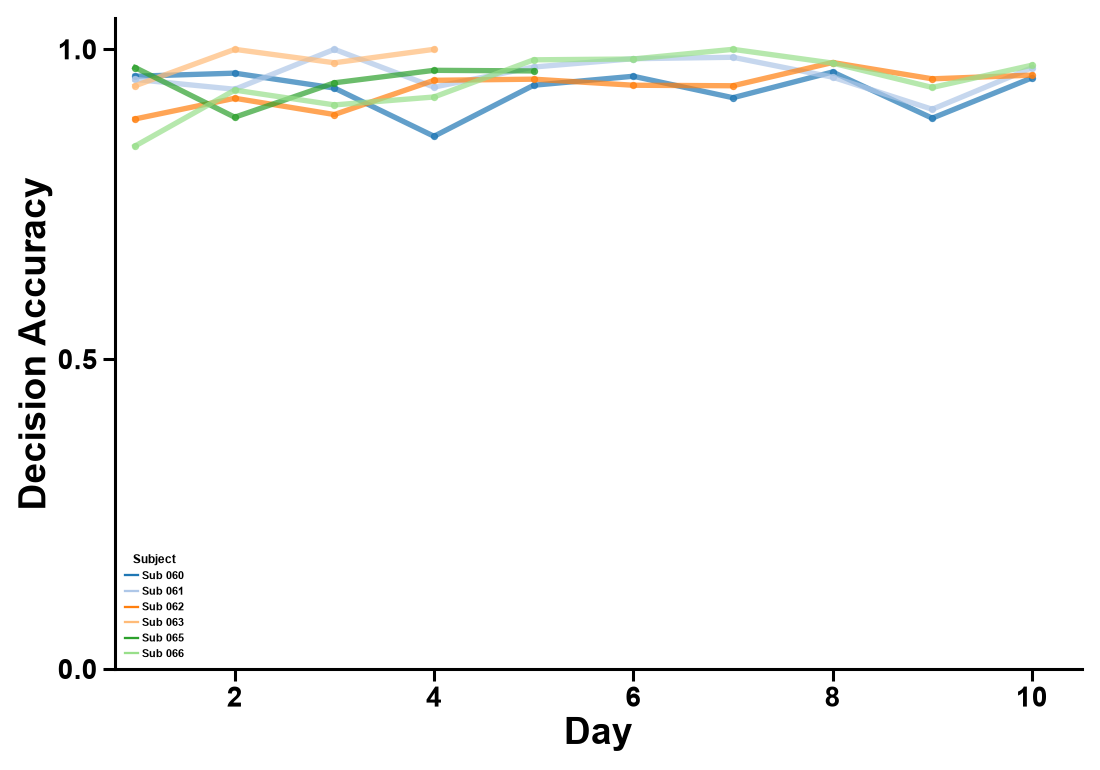

In [7]:
# Decision accuracy over training days. Each animal is a thin grey line (per-session
# decision_accuracy vs day index, day 1 = first session with data). The thick black line
# is the mean across animals at each day (using only animals that have data that day).
fig, ax = plot_decision_accuracy(
    quintuples,
    save=True,
    show_title=False,
    color_by_id=True,
    mean=False
)

In [ ]:
subjid = 51

hidden_rule_and_false_alarm(
    subjid, hidden_rule_21_sessions[subjid],
    odors=["D", "E", "G"],
    fa_label=None,
    show_title=False,
    show_legend=True,
    show_lines=True,
    lw_scale=1.0,
    marker_scale=1,
    save=True
)

# AB Odor Discrimination Task 

## Note: some visualization (e.g., cumulative rewards) moved to ab_learning notebook. 

In [ ]:
subjids={53: (20260506, 20260518), 
         55: (20260512, 20260529),
         56: (20260506, 20260529),
         57: (20260526, 20260529),
         58: (20260424, 20260506),
         59: (20260424, 20260506)}
subjids_2={45: (20251217, 20260109),
           46: (20251226, 20260106),
           47: (20251218, 20260105),
           48: (20251218, 20260109),
           49: (20260113, 20260128),
           50: (20260112, 20260120),
           51: (20260114, 20260116),
           52: (20260109, 20260119)}

poster={46: (20251226, 20260106),
        48: (20251218, 20260109),
        51: (20260114, 20260116),
        55: (20260430, 20260529),
        58: (20260423, 20260506),
        59: (20260423, 20260506)}


In [ ]:
# Decision accuracy over training days. Each animal is a thin grey line (per-session
# decision_accuracy vs day index, day 1 = first session with data). The thick black line
# is the mean across animals at each day (using only animals that have data that day).
fig, ax = plot_decision_accuracy(
    subjids_2,
    save=False,
    show_title=False,
    color_by_id=True,
    show_criterion=True,
    criterion=0.8,
    mean=False
)

In [ ]:
# Latency over time. Produces 2 plots: 1) X as time in arena, with rolling median response time + IQR band (log y).
# 2) X as trial index, with cumulative response time. 

plot_latency_over_time(subjids=subjids, dates=None, save=False, rewarded_only=False, window_size=20, step_size=5)

In [ ]:
# ITI over time. Produces 2 plots: 1) X as time in arena, with rolling median ITI + IQR band (log y).
# 2) X as trial index, with cumulative ITI. 

plot_iti_over_time(subjids=subjids, dates=None, save=False, window_size=40, step_size=10)

In [ ]:
# Latency over time: (1) time axis with rolling-median response time + IQR band (log y),
# (2) continuous trial axis with cumulative response time. rewarded_only toggles rewarded-only.
plot_latency_over_time(
    {53: (20260501, 20260518), 59: (20260423, 20260506)},
    rewarded_only=False, window_size=20, step_size=5, save=False,
)

# ITI over time (within-session inter-trial interval): same two views, no rewarded_only toggle.
plot_iti_over_time(
    {53: (20260501, 20260518), 59: (20260423, 20260506)},
    window_size=20, step_size=5, save=False,
)

# Single subject -> within-session gap shading + session boundaries are drawn:
# plot_latency_over_time(53, (20260501, 20260518), rewarded_only=True, save=False)

In [ ]:
fig1, ax1, fig2, ax2 = plot_decision_accuracy_rolling_average(
    subjid=40,
    dates=[20251206],
    window_size=30,
    step_size=6,
    include_avg=False,     
    hr_only=True,
    save=False,
)

In [ ]:
# Plots all choices for one or more sessions
choice_plots = plot_choice_history(
    subjid=45, 
    dates=[20260107], 
    fa_types=["FA_time_in", "FA_time_out"],
    save=False, 
    show_legend=True,
    title=False,
    lw_scale=3,
    xlim=(0,8500),
    marker_scale=3,)

In [ ]:
plt.close('all')

In [ ]:
print_cache_keys()

# Debugging
